# QM9 Checkpoint Visualization

This notebook calls `visualize_qm9_checkpoint_sample(...)` directly from `scripts/render_qm9_xz_slices.py`. Set the checkpoint and slice controls below, run one cell, and inspect the returned `source`, raw `condition`, `model_condition`, `initial_model_input`, `label`, and `output` tensors.


In [1]:
from pathlib import Path
import importlib
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts' / 'render_qm9_xz_slices.py').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root containing scripts/render_qm9_xz_slices.py')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import scripts.render_qm9_xz_slices as render_qm9_xz_slices

render_qm9_xz_slices = importlib.reload(render_qm9_xz_slices)
visualize_qm9_checkpoint_sample = render_qm9_xz_slices.visualize_qm9_checkpoint_sample


In [24]:
CKPT_PATH = REPO_ROOT / 'examples/QM9/experiment_16/checkpoints/last.ckpt'
#examples/QM9/experiment_15/checkpoints/ckpt_epoch=23_val_loss=0.006165.ckpt
SPLIT_FILE = REPO_ROOT / 'examples/QM9/experiment_5/split_4000.json'
#/scratch/gpfs/ROSENGROUP/aryan/electrai/examples/QM9/experiment_16_start/checkpoints/last.ckpt

SAMPLE_IDX = 95
SEED = None
PLANE = 'xy'
SLICE_INDEX = None
SLICE_FRAC = 0.5
DEVICE = 'auto'
OUTPUT_PATH = None

CKPT_PATH, SPLIT_FILE


(PosixPath('/scratch/gpfs/ROSENGROUP/aryan/electrai/examples/QM9/experiment_16/checkpoints/last.ckpt'),
 PosixPath('/scratch/gpfs/ROSENGROUP/aryan/electrai/examples/QM9/experiment_5/split_4000.json'))

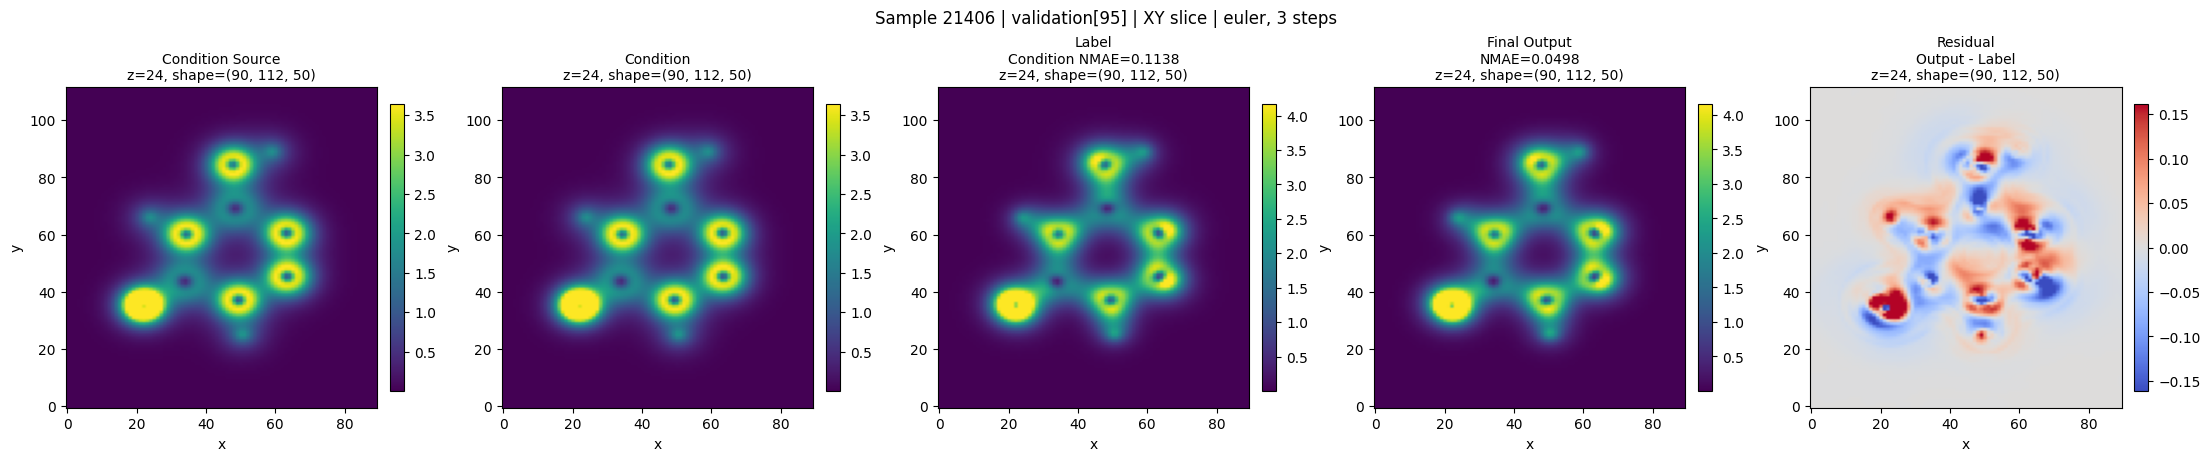

{'available_keys': ['condition',
  'condition_nmae',
  'condition_residual',
  'device',
  'figure',
  'initial_model_input',
  'initial_state',
  'label',
  'model_condition',
  'module_type',
  'n_steps',
  'nmae',
  'noise',
  'output',
  'output_path',
  'plane',
  'residual',
  'sample_id',
  'sample_idx',
  'slice_indices',
  'solver',
  'source'],
 'sample_id': '21406',
 'sample_idx': 95,
 'module_type': 'flow_with_time',
 'device': 'cuda',
 'plane': 'xy',
 'slice_indices': {'source': 24,
  'condition': 24,
  'label': 24,
  'output': 24,
  'residual': 24},
 'nmae': 0.04984741657972336,
 'source_shape': (1, 1, 90, 112, 50),
 'condition_shape': (1, 1, 90, 112, 50),
 'model_condition_shape': (1, 1, 90, 112, 50),
 'initial_model_input_shape': (1, 1, 90, 112, 50)}

In [25]:
result = visualize_qm9_checkpoint_sample(
    checkpoint_path=CKPT_PATH,
    split_file=SPLIT_FILE,
    sample_idx=SAMPLE_IDX,
    seed=SEED,
    n_steps=3,
    solver="euler",
    plane=PLANE,
    slice_index=SLICE_INDEX,
    slice_frac=SLICE_FRAC,
    output_path=OUTPUT_PATH,
    device=DEVICE,
    show=True,
)

source_tensor = result.get('source', result.get('noise'))
model_condition_tensor = result.get('model_condition', result.get('condition'))
initial_model_input_tensor = result.get('initial_model_input')

{
    'available_keys': sorted(result.keys()),
    'sample_id': result['sample_id'],
    'sample_idx': result['sample_idx'],
    'module_type': result['module_type'],
    'device': result['device'],
    'plane': result['plane'],
    'slice_indices': result['slice_indices'],
    'nmae': result['nmae'],
    'source_shape': None if source_tensor is None else tuple(source_tensor.shape),
    'condition_shape': tuple(result['condition'].shape),
    'model_condition_shape': None if model_condition_tensor is None else tuple(model_condition_tensor.shape),
    'initial_model_input_shape': None if initial_model_input_tensor is None else tuple(initial_model_input_tensor.shape),
}


In [ ]:
{
    key: tuple(result[key].shape)
    for key in (
        'source',
        'noise',
        'condition',
        'model_condition',
        'initial_state',
        'initial_model_input',
        'label',
        'output',
        'residual',
    )
    if key in result
}


In [4]:
!cd ..; cd examples/QM9; ls

experiment_1			    experiment_4
experiment_10_zero_residual_source  experiment_5
experiment_11			    experiment_6_conditioned_source
experiment_11_reflow		    experiment_7_residual_flow
experiment_1_7			    experiment_8_condition_aug
experiment_1_7_repeat		    experiment_9_sad_only_source
experiment_2			    experiment_test
experiment_3			    flowmatch_ablation_change_log.md


In [2]:
result = visualize_qm9_checkpoint_sample(
    checkpoint_path=(REPO_ROOT / 'examples/QM9/experiment_5/checkpoints_flow_match/last.ckpt'),
    split_file=SPLIT_FILE,
    sample_idx=SAMPLE_IDX,
    seed=SEED,
    n_steps=10,
    solver="heun",
    plane=PLANE,
    slice_index=SLICE_INDEX,
    slice_frac=SLICE_FRAC,
    output_path=OUTPUT_PATH,
    device=DEVICE,
    show=True,
)

source_tensor = result.get('source', result.get('noise'))
model_condition_tensor = result.get('model_condition', result.get('condition'))
initial_model_input_tensor = result.get('initial_model_input')

{
    'available_keys': sorted(result.keys()),
    'sample_id': result['sample_id'],
    'sample_idx': result['sample_idx'],
    'module_type': result['module_type'],
    'device': result['device'],
    'plane': result['plane'],
    'slice_indices': result['slice_indices'],
    'nmae': result['nmae'],
    'source_shape': None if source_tensor is None else tuple(source_tensor.shape),
    'condition_shape': tuple(result['condition'].shape),
    'model_condition_shape': None if model_condition_tensor is None else tuple(model_condition_tensor.shape),
    'initial_model_input_shape': None if initial_model_input_tensor is None else tuple(initial_model_input_tensor.shape),
}


NameError: name 'SPLIT_FILE' is not defined

In [5]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import scripts.render_qm9_xz_slices as render_qm9_xz_slices

render_qm9_xz_slices = importlib.reload(render_qm9_xz_slices)
cfg = render_qm9_xz_slices.load_cfg_from_checkpoint(Path(CKPT_PATH))
source_distribution = str(getattr(cfg, 'source_distribution', '')).lower()
if source_distribution not in {'conditioned', 'conditioned_gaussian'}:
    raise ValueError(
        f'Experiment-6 noise view requires a conditioned-source checkpoint, got source_distribution={source_distribution!r}. '
        'Point CKPT_PATH at examples/QM9/experiment_6_conditioned_source/checkpoints_flow_match/last.ckpt.'
    )

condition = result['condition'].float()
source = result['source'].float()

mean_scale = float(getattr(cfg, 'source_mean_scale', 0.0))
base_std = float(getattr(cfg, 'source_noise_base_std', 1.0))
guided_scale = float(getattr(cfg, 'source_noise_cond_scale', 0.0))
power = float(getattr(cfg, 'source_noise_power', 0.5))
blur_kernel = int(getattr(cfg, 'source_noise_blur_kernel', 1))
noise_eps = float(getattr(cfg, 'source_noise_eps', 1e-8))

guide = condition.clamp_min(0.0)
kernel = max(1, blur_kernel)
if kernel % 2 == 0:
    kernel += 1
if kernel > 1:
    guide = F.avg_pool3d(guide, kernel_size=kernel, stride=1, padding=kernel // 2)
flat = guide.flatten(start_dim=1)
scale = flat.amax(dim=1, keepdim=True).clamp_min(noise_eps)
guidance = guide / scale.view(-1, 1, 1, 1, 1)
std_map = base_std + guided_scale * guidance.pow(power)

additive_noise = source - mean_scale * condition
normalized_eps = additive_noise / std_map.clamp_min(1e-12)

def _to_volume(tensor: torch.Tensor) -> np.ndarray:
    array = tensor.detach().cpu().numpy()
    while array.ndim > 3:
        array = array[0]
    return np.asarray(array, dtype=np.float64)

volumes = {
    'std_map': _to_volume(std_map),
    'additive_noise': _to_volume(additive_noise),
    'normalized_eps': _to_volume(normalized_eps),
}
titles = {
    'std_map': 'Experiment 6 sigma(cond)',
    'additive_noise': 'Experiment 6 additive noise\nsource - mean_scale * condition',
    'normalized_eps': 'Experiment 6 normalized eps\n(source - mean_scale * condition) / sigma(cond)',
}

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5), constrained_layout=True)
slice_meta = {}
for ax, key in zip(axes, volumes, strict=True):
    slice_2d, axis_name, used_index, xlabel, ylabel = render_qm9_xz_slices.select_slice(
        volumes[key],
        PLANE,
        SLICE_INDEX,
        SLICE_FRAC,
    )
    slice_meta[key] = used_index
    finite = slice_2d[np.isfinite(slice_2d)]
    if finite.size:
        if key == 'std_map':
            vmin = float(np.percentile(finite, 1.0))
            vmax = float(np.percentile(finite, 99.0))
            cmap = 'viridis'
        else:
            bound = float(np.percentile(np.abs(finite), 99.0))
            bound = bound if bound > 0.0 else 1.0
            vmin, vmax = -bound, bound
            cmap = 'coolwarm'
    else:
        vmin, vmax, cmap = 0.0, 1.0, 'viridis'
    image = ax.imshow(slice_2d, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f"{titles[key]}\n{axis_name}={used_index}, shape={volumes[key].shape}", fontsize=10)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f"Experiment 6 source-noise view | sample {result['sample_id']} | validation[{result['sample_idx']}] | {PLANE.upper()} slice",
    fontsize=12,
)
plt.show()

{
    'source_distribution': source_distribution,
    'mean_scale': mean_scale,
    'base_std': base_std,
    'guided_scale': guided_scale,
    'power': power,
    'blur_kernel': kernel,
    'slice_indices': slice_meta,
    'std_map_range': (float(std_map.min()), float(std_map.max())),
    'additive_noise_range': (float(additive_noise.min()), float(additive_noise.max())),
    'normalized_eps_range': (float(normalized_eps.min()), float(normalized_eps.max())),
}


ValueError: Experiment-6 noise view requires a conditioned-source checkpoint, got source_distribution='condition_only'. Point CKPT_PATH at examples/QM9/experiment_6_conditioned_source/checkpoints_flow_match/last.ckpt.

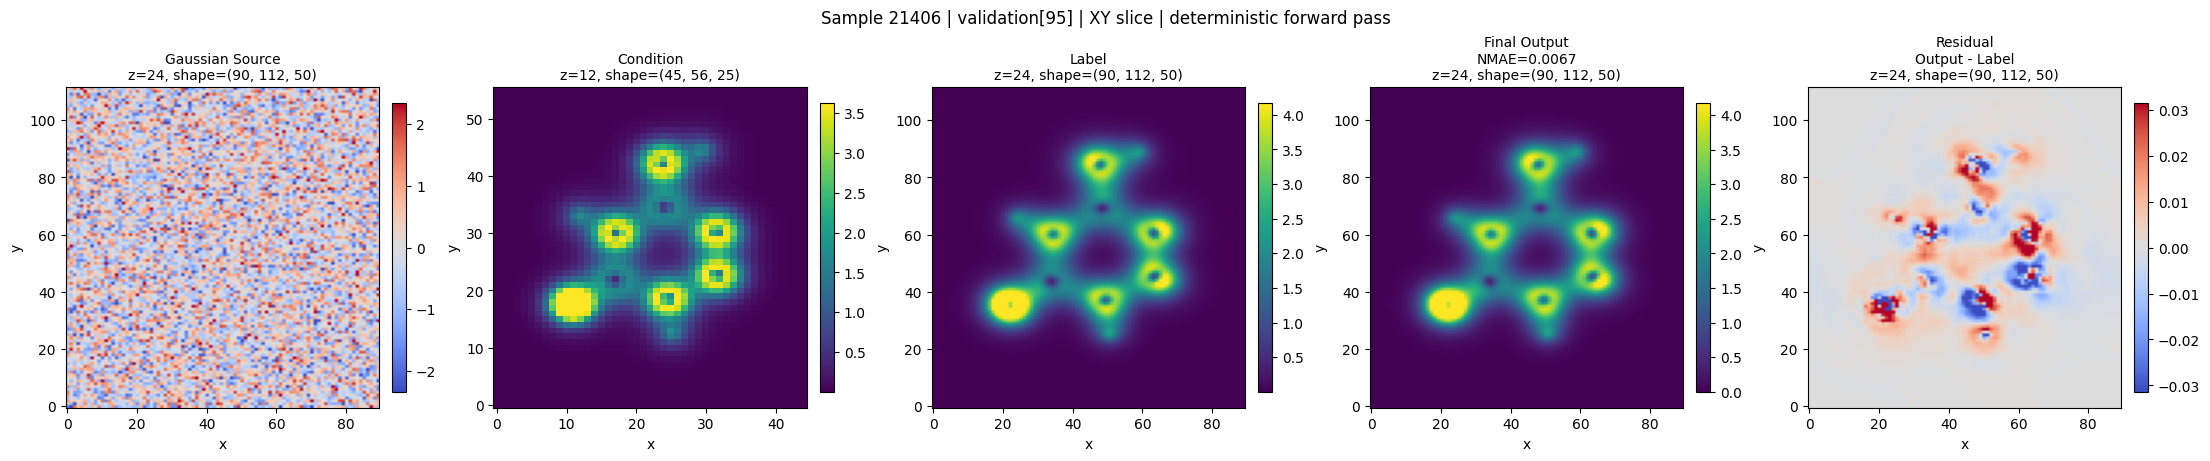

In [7]:
CKPT_PATH = REPO_ROOT / 'examples/QM9/experiment_5/checkpoints/last.ckpt'
SPLIT_FILE = REPO_ROOT / 'examples/QM9/experiment_5/split_4000.json'

SAMPLE_IDX = 95   # or None for random
SEED = None
PLANE = 'xy'      # or 'xz' / 'yz'
SLICE_INDEX = None
SLICE_FRAC = 0.5
DEVICE = 'auto'
OUTPUT_PATH = None

result = visualize_qm9_checkpoint_sample(
    checkpoint_path=CKPT_PATH,
    split_file=SPLIT_FILE,
    sample_idx=SAMPLE_IDX,
    seed=SEED,
    plane=PLANE,
    slice_index=SLICE_INDEX,
    slice_frac=SLICE_FRAC,
    output_path=OUTPUT_PATH,
    device=DEVICE,
    show=True,
)

